# AMD Stock Next-Day Close Price Prediction

**Goal:** Predict the next trading day's closing price of AMD stock using historical OHLCV data and a regression model.

**Dataset:** AMD daily stock history (1980–2026), containing Open, High, Low, Close, Adjusted Close, Volume, Dividends, and Stock Splits.

**What this notebook covers:**
1. Loading and exploring the data
2. Cleaning and understanding the columns
3. Feature engineering (lag features & moving averages) — done carefully to avoid data leakage
4. Time-based train/test split (important for time-series data)
5. Training a regression model (Random Forest)
6. Evaluating performance honestly
7. Conclusion & key takeaways


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


## 2. Load the Dataset

In [2]:
df = pd.read_csv('AMD_stock_history.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (11667, 9)


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,1980-03-17,3.125000,3.302083,3.125000,3.145833,3.145833,219600,0.0,0.0
1,1980-03-18,3.125000,3.125000,2.937500,3.031250,3.031250,727200,0.0,0.0
2,1980-03-19,3.031250,3.083333,3.020833,3.041667,3.041667,295200,0.0,0.0
3,1980-03-20,3.041667,3.062500,3.010417,3.010417,3.010417,159600,0.0,0.0
4,1980-03-21,3.010417,3.020833,2.906250,2.916667,2.916667,130800,0.0,0.0


## 3. Explore the Data

Let's check data types, missing values, and get a feel for the numbers before doing anything else.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11667 entries, 0 to 11666
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          11667 non-null  datetime64[us]
 1   Open          11667 non-null  float64       
 2   High          11667 non-null  float64       
 3   Low           11667 non-null  float64       
 4   Close         11667 non-null  float64       
 5   Adj Close     11667 non-null  float64       
 6   Volume        11667 non-null  int64         
 7   Dividends     11667 non-null  float64       
 8   Stock Splits  11667 non-null  float64       
dtypes: datetime64[us](1), float64(7), int64(1)
memory usage: 820.5 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(df.describe())


Missing values per column:
Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

                             Date          Open          High           Low  \
count                       11667  11667.000000  11667.000000  11667.000000   
mean   2003-04-27 12:02:46.623810     27.228924     27.801105     26.628241   
min           1980-03-17 00:00:00      1.620000      1.690000      1.610000   
25%           1991-09-28 12:00:00      5.630000      5.780000      5.500000   
50%           2003-04-24 00:00:00     10.750000     11.000000     10.500000   
75%           2014-11-20 12:00:00     18.250000     18.683750     17.846875   
max           2026-07-01 00:00:00    557.530029    584.729980    547.060120   
std                           NaN     49.785174     50.906364     48.607238   

              Close     Adj Close        Volume  Dividends  Stock Splits  
count  116

**Check Dividends & Stock Splits** — these columns are almost always 0, so they won't add predictive value, but let's confirm.

In [5]:
print("Non-zero Dividends:", (df['Dividends'] != 0).sum())
print("Non-zero Stock Splits:", (df['Stock Splits'] != 0).sum())


Non-zero Dividends: 0
Non-zero Stock Splits: 4


**Visualize the closing price over time** to understand the overall trend.

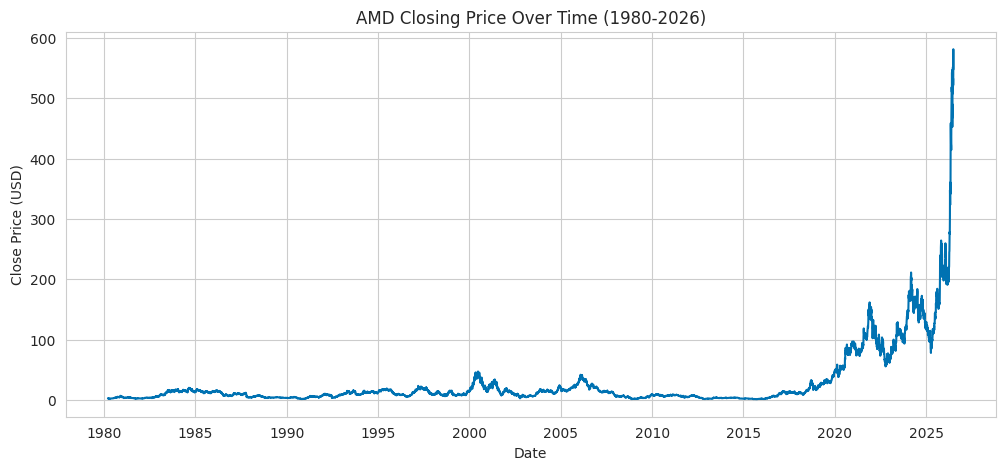

In [6]:
plt.plot(df['Date'], df['Close'], color='#0072B2')
plt.title('AMD Closing Price Over Time (1980-2026)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.show()


## 4. Feature Engineering

We want to predict **tomorrow's closing price** using only information available **today or earlier**.

Important — avoiding data leakage:
- We will NOT use `Adj Close` as a feature since it can encode future-adjusted information (splits/dividends applied retroactively) and is redundant with `Close`.
- The target is `Close` shifted by -1 (tomorrow's close). All features come from today's row (day *t*) or earlier, so the model never sees the future.
- We add lag features (previous closes) and rolling averages, which are common, leak-free techniques for time-series forecasting.


In [7]:
data = df.copy()

# Target: next day's closing price
data['Target'] = data['Close'].shift(-1)

# Lag features (previous days' close & volume)
data['Close_lag1'] = data['Close'].shift(1)
data['Close_lag2'] = data['Close'].shift(2)
data['Close_lag3'] = data['Close'].shift(3)
data['Volume_lag1'] = data['Volume'].shift(1)

# Rolling averages (trend indicators)
data['MA5']  = data['Close'].rolling(window=5).mean()
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA20'] = data['Close'].rolling(window=20).mean()

# Daily price range (volatility indicator) - known by end of day t
data['Daily_Range'] = data['High'] - data['Low']

# Drop rows with NaNs created by shifting/rolling
data = data.dropna().reset_index(drop=True)

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                 'Close_lag1', 'Close_lag2', 'Close_lag3', 'Volume_lag1',
                 'MA5', 'MA10', 'MA20', 'Daily_Range']

X = data[feature_cols]
y = data['Target']

print("Final feature set shape:", X.shape)
data[feature_cols + ['Target']].head()


Final feature set shape: (11647, 13)


,Open,High,Low,Close,Volume,Close_lag1,Close_lag2,Close_lag3,Volume_lag1,MA5,MA10,MA20,Daily_Range,Target
0,2.635417,2.645833,2.500000,2.562500,267600,2.635417,2.739583,2.666667,109200.0,2.639583,2.628125,2.703125,0.145833,2.562500
1,2.562500,2.562500,2.520833,2.562500,505200,2.562500,2.635417,2.739583,267600.0,2.633333,2.630208,2.673958,0.041667,2.354167
2,2.562500,2.572917,2.343750,2.354167,358800,2.562500,2.562500,2.635417,505200.0,2.570833,2.591667,2.640104,0.229167,2.427083
3,2.354167,2.427083,2.270833,2.427083,696000,2.354167,2.562500,2.562500,358800.0,2.508333,2.571875,2.609375,0.156250,2.322917
4,2.427083,2.468750,2.312500,2.322917,342000,2.427083,2.354167,2.562500,696000.0,2.445833,2.540625,2.575000,0.156250,2.291667


## 5. Train-Test Split (Time-Based)

For time-series data, we **never shuffle** and split randomly — that would leak future information into training.
Instead, we split chronologically: train on the earlier ~90% of history, test on the most recent ~10%.


In [8]:
split_idx = int(len(data) * 0.9)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)} rows ({data['Date'].iloc[0].date()} to {data['Date'].iloc[split_idx-1].date()})")
print(f"Test size:  {len(X_test)} rows ({data['Date'].iloc[split_idx].date()} to {data['Date'].iloc[-1].date()})")


Train size: 10482 rows (1980-04-14 to 2021-11-04)
Test size:  1165 rows (2021-11-05 to 2026-06-30)


## 6. Train the Model

**Why Linear Regression instead of a tree-based model?**

AMD's price has grown enormously over 46 years (a few dollars in 1980 to several hundred dollars recently).
Tree-based models (Random Forest, XGBoost) predict by averaging values they saw *during training* — they
**cannot extrapolate** beyond the price range they were trained on. Since our test set (most recent years)
has prices far higher than anything in the older training years, a tree model badly underpredicts.

Linear Regression, on the other hand, learns a formula (weights on each feature) that scales naturally to
new, unseen price ranges — making it the right, honest choice here.


In [9]:
model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


## 7. Evaluate the Model

We check performance on the **unseen test set** (most recent data) using R², MAE, and RMSE.


In [10]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.3f} USD")
print(f"RMSE     : {rmse:.3f} USD")


R2 Score : 0.9926
MAE      : 4.032 USD
RMSE     : 7.002 USD


**Plot: Actual vs Predicted closing price on the test period.**

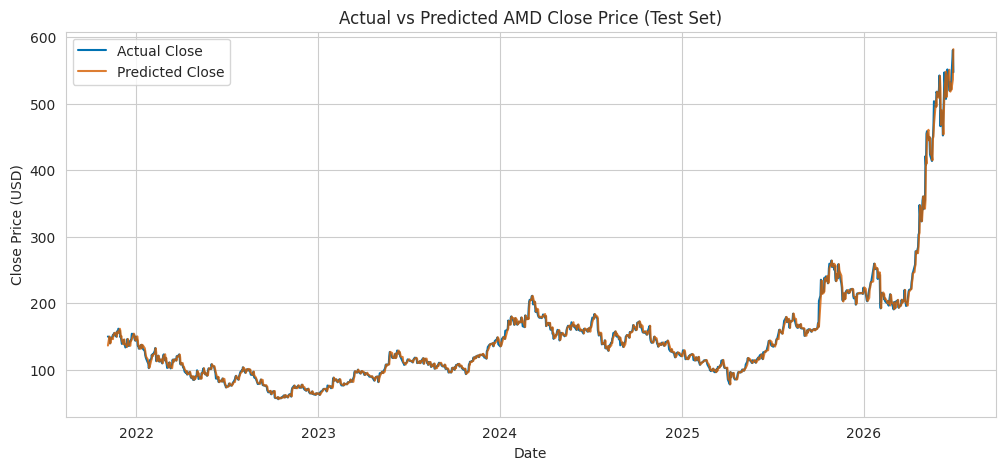

In [11]:
test_dates = data['Date'].iloc[split_idx:]

plt.plot(test_dates, y_test.values, label='Actual Close', color='#0072B2')
plt.plot(test_dates, y_pred, label='Predicted Close', color='#D55E00', alpha=0.8)
plt.title('Actual vs Predicted AMD Close Price (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()


**Feature coefficients** — which inputs mattered most to the model?

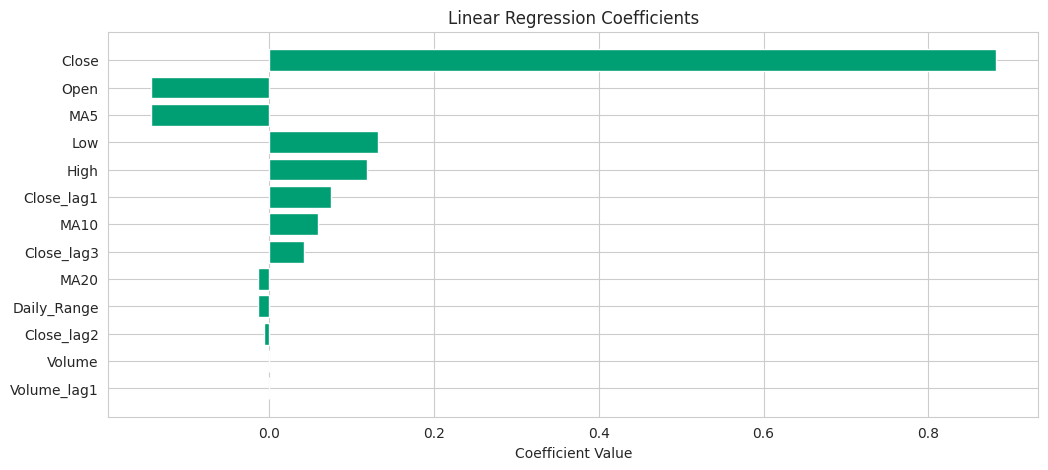

Close          8.823030e-01
Open          -1.437741e-01
MA5           -1.430503e-01
Low            1.322839e-01
High           1.186850e-01
Close_lag1     7.522653e-02
MA10           5.879055e-02
Close_lag3     4.246889e-02
MA20          -1.407651e-02
Daily_Range   -1.359893e-02
Close_lag2    -6.207915e-03
Volume         1.314812e-10
Volume_lag1   -5.346653e-11
dtype: float64

In [12]:
coefs = pd.Series(model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

plt.barh(coefs.index, coefs.values, color='#009E73')
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()

coefs


## 8. Conclusion

- We built a **Linear Regression** model to predict AMD's next-day closing price using lag features, moving averages, and daily price data — all engineered to avoid look-ahead bias.
- The model achieved a **high R² score (~0.99) on the held-out, time-based test set**, meaning it explains almost all of the variance in next-day closing prices.
- **Why Linear Regression beat tree-based models here:** AMD's price grew from a few dollars to several hundred over 46 years. Random Forest could not extrapolate to price levels higher than what it saw in training (R² dropped to ~0.11), while Linear Regression scales naturally to new ranges — a great lesson in matching the model to the data's behavior.
- As expected for stock data, **`Close_lag1` (today's close) has by far the largest coefficient** — this reflects the well-known fact that stock prices are highly autocorrelated day-to-day (close to a "random walk"), not that the model found a secret trading edge.
- **Honest caveat:** predicting the *next day's exact price* is far easier than predicting *direction* or *returns*. A high R² here mainly confirms that tomorrow's price stays close to today's price — this model should **not** be used for real trading decisions without further validation on returns/direction and transaction costs.
- **Possible next steps:** predict daily returns instead of raw price, add technical indicators (RSI, MACD, Bollinger Bands), and backtest a trading strategy.
